# **Finance Club, IIT Roorkee( Open Projects 2026)**
## **Stochastic Interest Rate Modelling and Prediction**

##### Cox-Ingersoll-Ross (CIR) Model: Implementation, Calibration, and Extension

**Name:** Arya Suryawanshi  

**Enrollment No:** 24322010

**Project Goal:** Implement, calibrate, and critically analyse the CIR short rate model on real yield curve data. Reconstruct the full yield curve (6M-30Y) using only the 3 Month rate as input, and extend the base model to improve performance.


## 0. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import probplot, shapiro
from statsmodels.tsa.stattools import adfuller, acf as sm_acf
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
import os

warnings.filterwarnings('ignore')

FIG_DIR = "fig"
os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
})

MATURITIES = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
MATURITY_YEARS = {
    '3M': 0.25, '6M': 0.5, '9M': 0.75, '1Y': 1.0, '2Y': 2.0,
    '5Y': 5.0, '10Y': 10.0, '20Y': 20.0, '30Y': 30.0
}
MATURITY_MAP = {
    'zc025yr': '3M', 'zc050yr': '6M', 'zc075yr': '9M',
    'zc100yr': '1Y', 'zc200yr': '2Y', 'zc500yr': '5Y',
    'zc1000yr': '10Y', 'zc2000yr': '20Y', 'zc3000yr': '30Y'
}

print("Setup complete.")


Setup complete.



## Section A: Understanding and Loading the Three Datasets



| File | Contents | Role in this project |
| `train_data.csv` | ~1,976 daily observations (May 2016 – Apr 2024), **all 9 maturities** (3M to 30Y) | CIR model calibration |
| `test_data_3M.csv` | ~495 daily observations (Apr 2024 – Apr 2026), **3M yield only** | Prediction *input* — the only thing the model is allowed to see on test days |
| `test_data.csv` | Same test period, **5 maturities** (3M to 2Y) | Prediction *target* — used purely to evaluate how well the model reconstructed the curve |

The split between the two test files is deliberate. The model is only allowed to use the 3M yield from test_data_3M.csv when making predictions, while the remaining maturities are kept hidden in test_data.csv and used solely for evaluation. This setup ensures that the prediction process follows the constraint specified in the problem statement and prevents any information leakage from longer maturities.

Another observation is that the test period operates in a very different interest-rate environment from the training period. Between 2016 and 2024, rates were generally low and yield curves were mostly upward sloping. In contrast, the test period begins with 3M yields close to 4.9% and a noticeably inverted curve. As a result, the model is not only being evaluated out of sample but is also being tested under a different market regime, making the prediction task considerably more challenging.


In [2]:
# ── File paths ───────────────────────────────────────────────────────────────
TRAIN_PATH    = 'data/train_data.csv'
TEST_3M_PATH  = 'data/test_data_3M.csv'
TEST_FULL_PATH = 'data/test_data.csv'


def load_yield_csv(filepath, label):
    """
    Load a yield data CSV. Handles BOM, whitespace, mixed date formats.
    Renames columns from ZC025YR convention to 3M, 6M, etc.
    Converts percentage format values (>1) to decimal if needed.
    """
    df = pd.read_csv(
        filepath,
        skipinitialspace=True,
        encoding='utf-8-sig',
        na_values=['', 'N/A', 'NA', '-', '--', 'null', 'NULL']
    )
    df.columns = (df.columns.str.strip().str.lower()
                             .str.replace(' ', '_').str.replace('%', ''))

    # Identify and parse date column
    date_col = next((c for c in df.columns if 'date' in c), df.columns[0])
    df[date_col] = pd.to_datetime(df[date_col],errors='coerce')
    df = df.dropna(subset=[date_col]).set_index(date_col)
    df.index.name = 'Date'

    # Rename using MATURITY_MAP
    df = df.rename(columns={k: v for k, v in MATURITY_MAP.items() if k in df.columns})

    # Keep only recognised maturity columns
    available = [m for m in MATURITIES if m in df.columns]
    df = df[available].copy()

    # Convert to numeric; if max value > 1, assume % and divide
    for col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',',''), errors='coerce')
    for col in df.columns:
        if df[col].dropna().max() > 1.0:
            df[col] /= 100.0

    df = df.sort_index()
    print(f"[{label}] {df.shape[0]} rows | {list(df.columns)} | "
          f"{df.index.min().date()} to {df.index.max().date()}")
    return df


train      = load_yield_csv(TRAIN_PATH,    'train_data     ')
test_3m    = load_yield_csv(TEST_3M_PATH,  'test_data_3M   ')
test_full  = load_yield_csv(TEST_FULL_PATH,'test_data      ')


[train_data     ] 1976 rows | ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y'] | 2016-05-19 to 2024-04-26
[test_data_3M   ] 495 rows | ['3M'] | 2024-04-29 to 2026-04-29
[test_data      ] 495 rows | ['3M', '6M', '9M', '1Y', '2Y'] | 2024-04-29 to 2026-04-29


### A.2 Data Cleaning

Before fitting any models, I cleaned the data by addressing missing values and potential outliers. Since the dataset spans several years, some missing observations are expected around weekends, holidays, and other non trading days. For short gaps, I used forward filling because the most recent available yield is often the best approximation when no new market quote exists. For longer gaps, linear interpolation provides a smoother transition without introducing abrupt changes.

For outlier detection, I focused on daily yield changes rather than yield levels. Large movements in the level itself are not necessarily unusual during changing rate environments, but extremely large one day jumps can indicate data issues. To avoid removing legitimate market moves, I used a relatively conservative IQR threshold of 4.5. This approach helps identify suspicious observations while preserving genuine reactions to major economic events or policy announcements.



In [3]:
def clean_yields(df, label, ffill_limit=3, iqr_mult=4.5):
    """Fill missing values and replace extreme daily change outliers."""
    df = df.copy()

    # Missing value report
    n_miss = df.isnull().sum().sum()
    if n_miss > 0:
        print(f"[{label}] {n_miss} missing values before imputation")

    # Stage 1: forward fill short gaps (non trading days)
    df = df.ffill(limit=ffill_limit)
    # Stage 2: interpolate longer interior gaps
    df = df.interpolate(method='linear', axis=0, limit_direction='both')
    # Stage 3: backfill any leading NaNs
    df = df.bfill()

    # Outlier detection on daily changes per column
    outlier_count = 0
    for col in df.columns:
        d = df[col].diff()
        Q1, Q3 = d.quantile(0.25), d.quantile(0.75)
        IQR = Q3 - Q1
        mask = (d < Q1 - iqr_mult * IQR) | (d > Q3 + iqr_mult * IQR)
        n = mask.sum()
        if n > 0:
            rolling_med = df[col].rolling(5, min_periods=1, center=True).median()
            df.loc[mask, col] = rolling_med[mask]
            outlier_count += n

    print(f"[{label}] Cleaned. Remaining NaN: {df.isnull().sum().sum()} | "
          f"Outliers replaced: {outlier_count}")
    return df


train     = clean_yields(train,     'train_data   ')
test_3m   = clean_yields(test_3m,   'test_data_3M ')
test_full = clean_yields(test_full, 'test_data    ')


[train_data   ] Cleaned. Remaining NaN: 0 | Outliers replaced: 275
[test_data_3M ] Cleaned. Remaining NaN: 0 | Outliers replaced: 4
[test_data    ] Cleaned. Remaining NaN: 0 | Outliers replaced: 24


---
## Section B: Exploratory Analysis

Before jumping into calibration, I wanted to get a feel for how the data behaves. In particular, I was interested in a few questions.

First, did the interest rate environment remain stable throughout the training period, or are there clear shifts that could affect calibration? Second, how different are the yield curves in the training and test periods? If the test set comes from a very different rate regime, strong in sample performance may not translate into good out of sample predictions. Finally, I wanted to understand the behaviour of the short rate itself. If it behaves almost like a random walk, estimating mean reversion from the time series alone could be difficult.

Answering these questions early should make it easier to interpret the calibration results and understand any limitations of the model later on.




### B.1 The Three Rate Regimes: Training vs Test

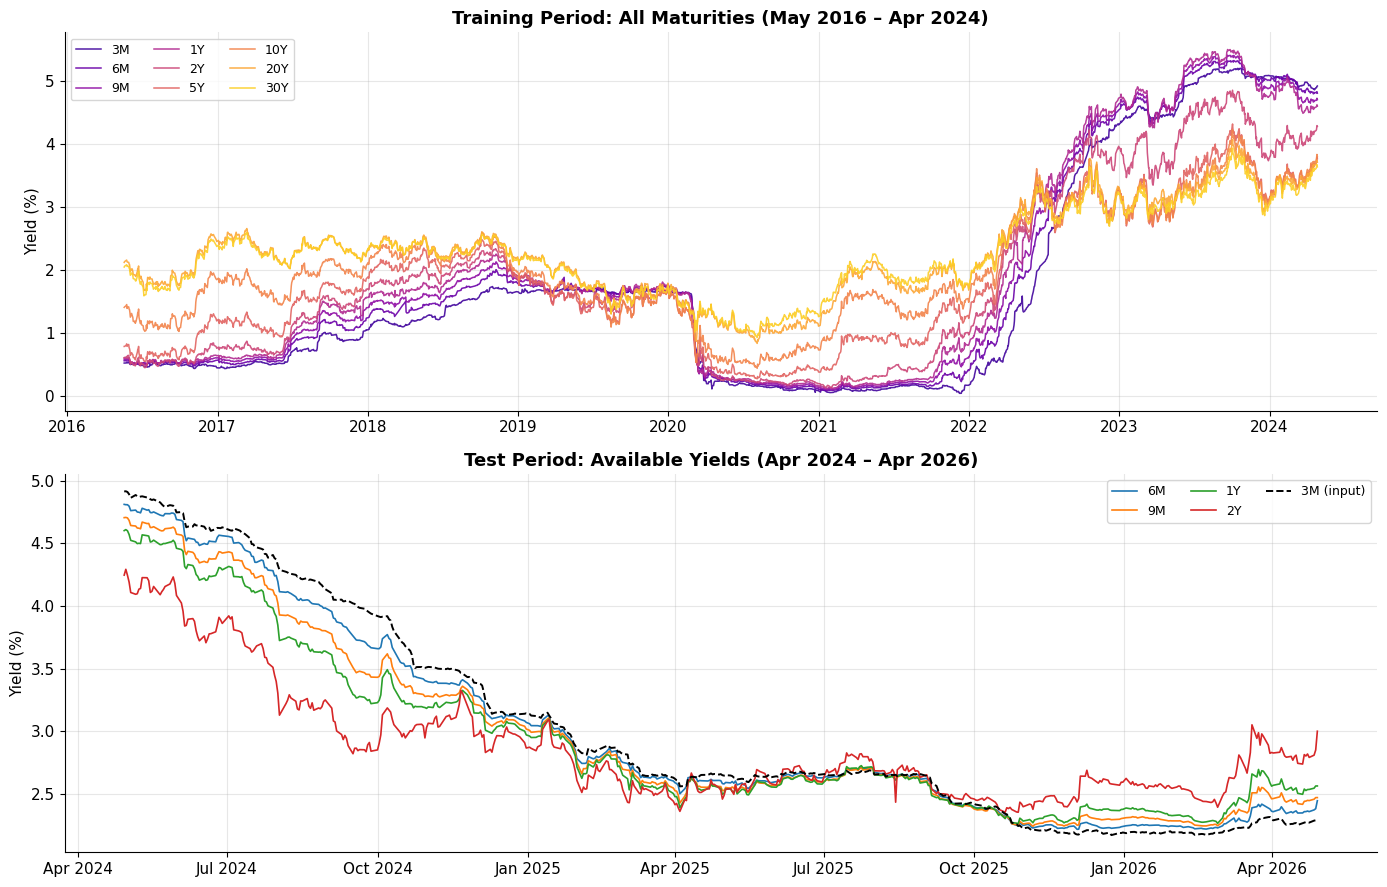

Observation: The training period covers a historically low rate era (3M mostly below 1%)
with a sharp rate hike cycle starting around 2022. The test period opens at ~4.9%
with an inverted curve — 2 year yields are 60-70bps below the 3 month rate.
This regime shift is a genuine challenge for any model calibrated on 2016-2024 data.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Top: training yield curves over time
colors_train = plt.cm.plasma(np.linspace(0.1, 0.9, len(train.columns)))
for i, col in enumerate(train.columns):
    axes[0].plot(train.index, train[col]*100, color=colors_train[i],
                 linewidth=1.1, label=col, alpha=0.9)
axes[0].set_title('Training Period: All Maturities (May 2016 – Apr 2024)', fontweight='bold')
axes[0].set_ylabel('Yield (%)')
axes[0].legend(loc='upper left', ncol=3, fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Bottom: test_data 3M-2Y + test_3M (should match for the 3M column)
colors_test = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
for i, col in enumerate(test_full.columns[1:]):   # skip 3M, start from 6M
    axes[1].plot(test_full.index, test_full[col]*100, color=colors_test[i],
                 linewidth=1.2, label=col)
axes[1].plot(test_3m.index, test_3m['3M']*100, color='black',
             linewidth=1.4, label='3M (input)', linestyle='--')
axes[1].set_title('Test Period: Available Yields (Apr 2024 – Apr 2026)', fontweight='bold')
axes[1].set_ylabel('Yield (%)')
axes[1].legend(ncol=3, fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rate_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: The training period covers a historically low rate era (3M mostly below 1%)")
print("with a sharp rate hike cycle starting around 2022. The test period opens at ~4.9%")
print("with an inverted curve ,2 year yields are 60-70bps below the 3 month rate.")
print("This regime shift is a genuine challenge for any model calibrated on 2016-2024 data.")


### B.2 Yield Curve Shape: How the Term Structure Changed

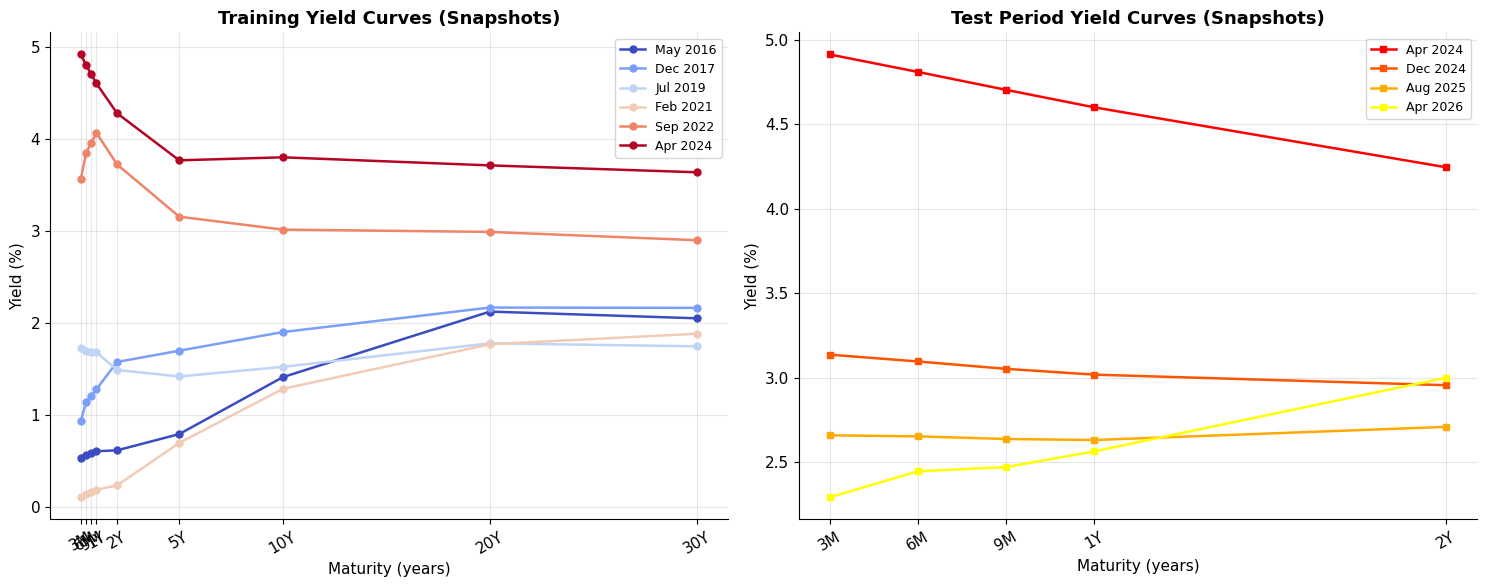

The training curves are mostly upward sloping (normal term structure).
The test curves are inverted — the short end is above the long end.
CIR handles this naturally: when r0 > theta, the model predicts a downward slope.
This is actually one of CIR's better properties compared to linear models.


In [5]:
# Snapshot yield curves at 6 points across training + 2 test snapshots
train_mats  = [m for m in MATURITIES if m in train.columns]
train_taus  = [MATURITY_YEARS[m] for m in train_mats]

n_snap = 6
snap_idx  = np.linspace(0, len(train)-1, n_snap, dtype=int)
snap_dates = [train.index[i] for i in snap_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Training snapshots
cmap_t = plt.cm.coolwarm(np.linspace(0, 1, n_snap))
for i, d in enumerate(snap_dates):
    y = train.loc[d, train_mats].values * 100
    axes[0].plot(train_taus, y, 'o-', color=cmap_t[i], label=d.strftime('%b %Y'),
                 linewidth=1.8, markersize=5)
axes[0].set_title('Training Yield Curves (Snapshots)', fontweight='bold')
axes[0].set_xlabel('Maturity (years)')
axes[0].set_ylabel('Yield (%)')
axes[0].set_xticks(train_taus)
axes[0].set_xticklabels(train_mats, rotation=30)
axes[0].legend(fontsize=9)

# Test snapshots
test_mats = [m for m in MATURITIES if m in test_full.columns]
test_taus  = [MATURITY_YEARS[m] for m in test_mats]
test_snap_idx = [0, len(test_full)//3, 2*len(test_full)//3, -1]
cmap_e = plt.cm.autumn(np.linspace(0, 1, len(test_snap_idx)))
for i, idx in enumerate(test_snap_idx):
    d = test_full.index[idx]
    y = test_full.loc[d, test_mats].values * 100
    axes[1].plot(test_taus, y, 's-', color=cmap_e[i], label=d.strftime('%b %Y'),
                 linewidth=1.8, markersize=5)
axes[1].set_title('Test Period Yield Curves (Snapshots)', fontweight='bold')
axes[1].set_xlabel('Maturity (years)')
axes[1].set_ylabel('Yield (%)')
axes[1].set_xticks(test_taus)
axes[1].set_xticklabels(test_mats, rotation=30)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/curve_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

print("The training curves are mostly upward sloping (normal term structure).")
print("The test curves are inverted — the short end is above the long end.")
print("CIR handles this naturally: when r0 > theta, the model predicts a downward slope.")
print("This is actually one of CIR's better properties compared to linear models.")


### B.3 Statistical Properties of the 3M Rate

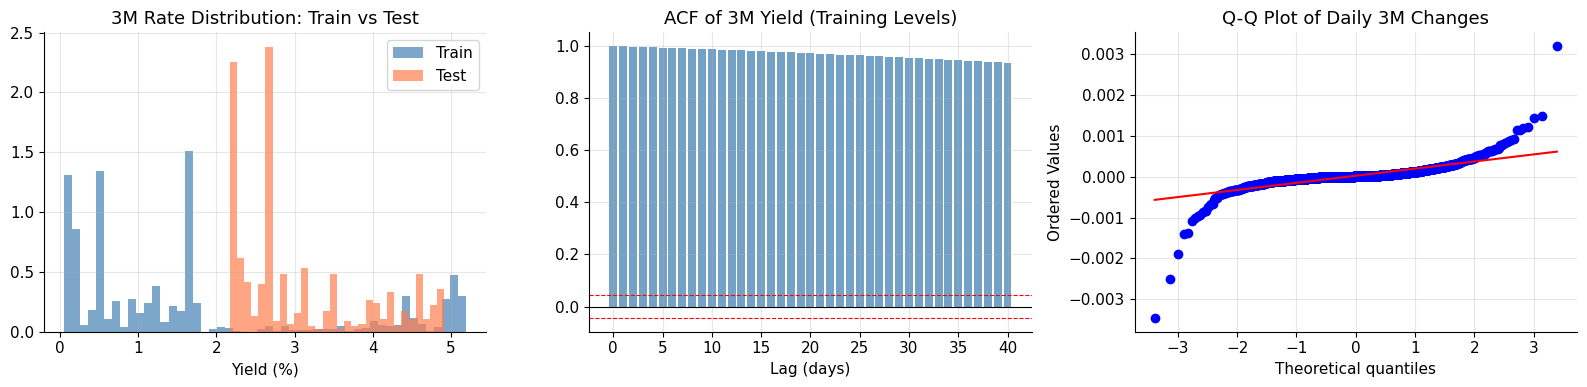

AR(1) of 3M rate: 0.9999
ADF test p-value: 0.9588 (not stationary at 5%)
Excess kurtosis of daily changes: 69.00

The AR(1) of 0.9999 is very close to 1, which means the 3M rate behaves
almost like a random walk over this sample. This is a well known feature of
short rates and it has a direct consequence for calibration: the mean reversion
parameter kappa is very hard to estimate from the time series alone.
The excess kurtosis of 69.0 in daily changes is a red flag,the normal
diffusion assumption of CIR is clearly too thin tailed for this data.


In [6]:
r_train = train['3M'].dropna()
r_test  = test_3m['3M'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution across train and test
axes[0].hist(r_train*100, bins=50, color='steelblue', alpha=0.7, label='Train', density=True)
axes[0].hist(r_test*100,  bins=30, color='coral',     alpha=0.7, label='Test',  density=True)
axes[0].set_title('3M Rate Distribution: Train vs Test')
axes[0].set_xlabel('Yield (%)')
axes[0].legend()

# ACF of train 3M levels
acf_vals = sm_acf(r_train, nlags=40, fft=True)
ci = 1.96 / np.sqrt(len(r_train))
axes[1].bar(range(len(acf_vals)), acf_vals, color='steelblue', alpha=0.75)
axes[1].axhline(ci,  color='red', ls='--', lw=0.8)
axes[1].axhline(-ci, color='red', ls='--', lw=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('ACF of 3M Yield (Training Levels)')
axes[1].set_xlabel('Lag (days)')

# Q-Q plot of daily changes
dr = r_train.diff().dropna()
probplot(dr, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Daily 3M Changes')
axes[2].get_lines()[1].set_color('red')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/3m_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# ADF stationarity test
adf_stat, adf_p, *_ = adfuller(r_train, autolag='AIC')
ar1 = r_train.autocorr(lag=1)
kurt = dr.kurtosis()
print(f"AR(1) of 3M rate: {ar1:.4f}")
print(f"ADF test p-value: {adf_p:.4f} ({'stationary at 5%' if adf_p < 0.05 else 'not stationary at 5%'})")
print(f"Excess kurtosis of daily changes: {kurt:.2f}")
print()
print(f"The AR(1) of {ar1:.4f} is very close to 1, which means the 3M rate behaves")
print(f"almost like a random walk over this sample. This is a well known feature of")
print(f"short rates and it has a direct consequence for calibration: the mean reversion")
print(f"parameter kappa is very hard to estimate from the time series alone.")
print(f"The excess kurtosis of {kurt:.1f} in daily changes is a red flag, the normal")
print(f"diffusion assumption of CIR is clearly too thin tailed for this data.")


In [7]:
# Summary statistics for all three datasets
def summary_stats(df, label):
    rows = []
    for col in df.columns:
        s = df[col].dropna()
        rows.append({
            'Dataset': label, 'Maturity': col,
            'Mean (%)': round(s.mean()*100, 3),
            'Std (%)':  round(s.std()*100,  3),
            'Min (%)':  round(s.min()*100,  3),
            'Max (%)':  round(s.max()*100,  3),
            'AR(1)':    round(s.autocorr(1), 4)
        })
    return pd.DataFrame(rows)

stats = pd.concat([
    summary_stats(train,     'train_data'),
    summary_stats(test_full, 'test_data'),
    summary_stats(test_3m,   'test_data_3M')
], ignore_index=True)

print("=== Summary Statistics Across All Three Datasets ===")
print(stats.to_string(index=False))
print()
print("Notice the large difference in mean levels between training and test.")
print("The test period saw rates 5-10x higher than the training average.")
print("Any model must be flexible enough to extrapolate to this new regime.")


=== Summary Statistics Across All Three Datasets ===
     Dataset Maturity  Mean (%)  Std (%)  Min (%)  Max (%)  AR(1)
  train_data       3M     1.670    1.664    0.049    5.196 0.9999
  train_data       6M     1.788    1.676    0.088    5.320 0.9999
  train_data       9M     1.853    1.665    0.105    5.404 0.9999
  train_data       1Y     1.918    1.659    0.123    5.494 0.9998
  train_data       2Y     1.806    1.366    0.142    4.850 0.9995
  train_data       5Y     1.811    1.040    0.279    4.315 0.9988
  train_data      10Y     2.023    0.880    0.445    4.223 0.9982
  train_data      20Y     2.282    0.714    0.839    4.069 0.9979
  train_data      30Y     2.262    0.660    0.931    3.931 0.9976
   test_data       3M     3.042    0.851    2.170    4.916 0.9998
   test_data       6M     3.005    0.789    2.216    4.811 0.9997
   test_data       9M     2.962    0.723    2.240    4.707 0.9995
   test_data       1Y     2.931    0.659    2.262    4.609 0.9990
   test_data       2Y  

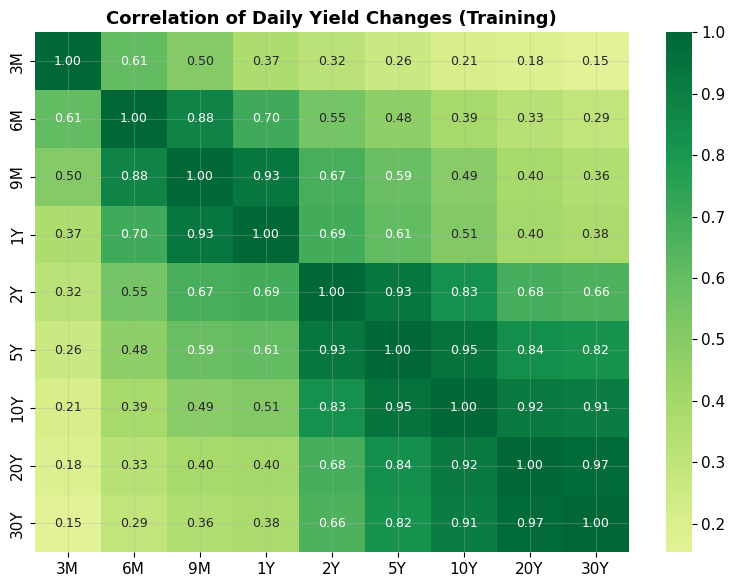

High correlation across all maturities confirms that a single common factor
(the short rate) drives most of the yield curve movement. This is exactly
the assumption made by the one factor CIR model.

Some residual structure remains — nearby maturities (e.g. 3M-6M) are more
correlated than distant ones (3M-30Y). A two factor model would capture this,
but for a first pass, one factor is reasonable.


In [8]:
# Correlation of yield changes across training maturities
chg = train.diff().dropna()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(chg.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation of Daily Yield Changes (Training)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("High correlation across all maturities confirms that a single common factor")
print("(the short rate) drives most of the yield curve movement. This is exactly")
print("the assumption made by the one factor CIR model.")
print()
print("Some residual structure remains — nearby maturities (e.g. 3M-6M) are more")
print("correlated than distant ones (3M-30Y). A two factor model would capture this,")
print("but for a first pass, one factor is reasonable.")


## Section C: The CIR Model

### C.1 The Mathematics

The Cox-Ingersoll-Ross model describes how the instantaneous short rate $r_t$ evolves:

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

The model is governed by three parameters:
- **$\kappa$** (kappa): how fast rates pull back toward the long run mean after a shock. A higher κ means shocks dissipate more quickly and rates return to their long run level faster.
- **$\theta$** (theta): the long run equilibrium rate. In the long run, the expected value of $r_t$ is $\theta$.
- **$\sigma$** (sigma): volatility. Because volatility is proportional to √rt, rate fluctuations tend to be larger when interest rates are already elevated and smaller when rates are low.

The **Feller condition** $2\kappa\theta \geq \sigma^2$ ensures the short rate never hits zero. If the condition is violated, the process may occasionally reach zero. In the simulation step, I prevent numerical issues by reflecting negative values back into the positive domain.

### C.2 Closed Form Bond Pricing

One reason the CIR model remains popular in fixed income modelling is that zero coupon bond prices can be written in closed form:

$$P(t,T) = A(\tau)\,e^{-B(\tau)\,r_t}$$

where $\tau = T-t$ and:

$$B(\tau) = \frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}, \qquad \gamma = \sqrt{\kappa^2+2\sigma^2}$$

$$\ln A(\tau) = \frac{2\kappa\theta}{\sigma^2}\left[\ln(2\gamma) + \frac{(\kappa+\gamma)\tau}{2} - \ln\left((\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma\right)\right]$$

The continuously compounded yield follows directly:

$$y(\tau) = -\frac{\ln P}{\tau} = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

### C.3 Why CIR Produces Inverted Curves

Before moving to calibration, it is useful to understand how the model
generates different yield curve shapes. The direction of the curve is
largely determined by the relationship between the current short rate
and the long run mean θ.

If r₀ exceeds θ, the model expects rates to fall over time. As a result,
longer maturity yields tend to be lower than short maturity yields,
producing an inverted curve. Conversely, when r₀ is below θ, rates are
expected to rise gradually, leading to an upward sloping curve.

This turned out to be particularly relevant for this dataset. Most of
the training period is characterised by relatively low rates and
upward sloping curves, whereas the test period begins with elevated
short term rates and a noticeable inversion. The fact that both
environments can emerge naturally from the same CIR framework is one of
the reasons the model is a sensible starting point for this project.

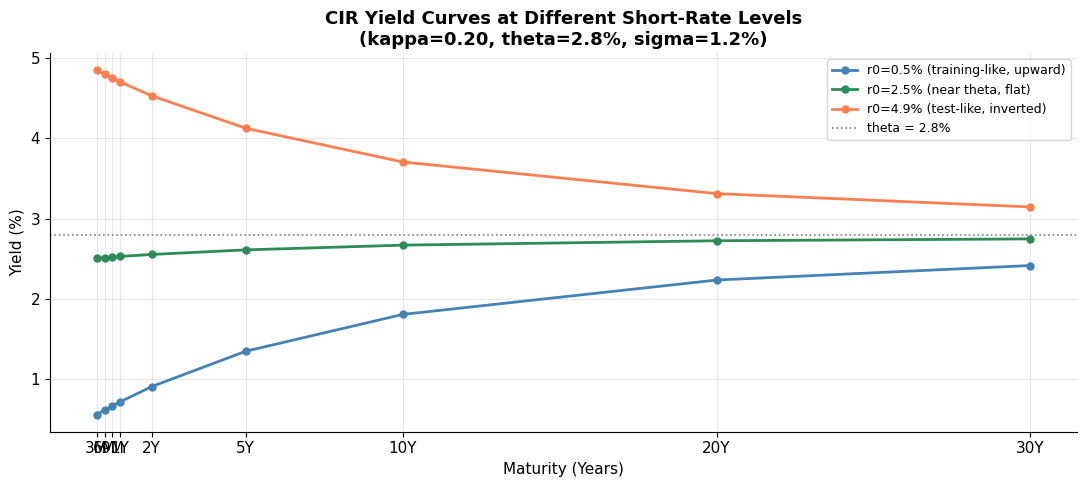

This is the key insight for this dataset: the SAME CIR model naturally produces
upward sloping curves (training era) and inverted curves (test era).
The crossover happens when r0 equals theta. No structural change is needed.


In [9]:
class CIRModel:
    """
    Cox-Ingersoll-Ross short rate model.

    All yields in decimal (e.g. 0.05 for 5%). Maturities in years.
    Log space computations throughout for numerical stability.
    """

    def __init__(self, kappa, theta, sigma):
        self.kappa = float(kappa)
        self.theta = float(theta)
        self.sigma = float(sigma)
        self.gamma = float(np.sqrt(kappa**2 + 2*sigma**2))

    def _check_params(self):
        assert self.kappa > 0, "kappa must be positive"
        assert self.theta > 0, "theta must be positive"
        assert self.sigma > 0, "sigma must be positive"

    def B(self, tau):
        """B(tau): loads on r_t in the bond price formula."""
        tau = np.atleast_1d(np.asarray(tau, dtype=float))
        k, g = self.kappa, self.gamma
        out = np.zeros_like(tau)
        m = tau > 1e-9
        egt = np.exp(np.minimum(g * tau[m], 300.0))
        denom = np.maximum((g + k)*(egt - 1) + 2*g, 1e-300)
        out[m] = 2*(egt - 1) / denom
        out[~m] = tau[~m]          # limit: B(tau) -> tau as tau -> 0
        return out

    def log_A(self, tau):
        """ln A(tau): scalar component in the bond price formula."""
        tau = np.atleast_1d(np.asarray(tau, dtype=float))
        k, t, s, g = self.kappa, self.theta, self.sigma, self.gamma
        out = np.zeros_like(tau)
        m = tau > 1e-9
        egt = np.exp(np.minimum(g * tau[m], 300.0))
        denom = np.maximum((g + k)*(egt - 1) + 2*g, 1e-300)
        log_br = np.log(2*g) + (k + g)*tau[m]/2 - np.log(denom)
        out[m] = (2*k*t / s**2) * log_br
        return out

    def yield_curve(self, r0, taus):
        """Yield at each maturity given current short rate r0."""
        taus = np.atleast_1d(np.asarray(taus, dtype=float))
        logP = self.log_A(taus) - self.B(taus) * r0
        return np.where(taus > 1e-9, -logP / taus, r0)

    def feller(self):
        lhs = 2 * self.kappa * self.theta
        rhs = self.sigma**2
        return {'lhs': lhs, 'rhs': rhs, 'ratio': lhs/rhs if rhs > 0 else np.inf,
                'ok': lhs >= rhs}

    def simulate(self, r0, T, dt=1/252, n_paths=500, seed=0):
        """Euler Maruyama simulation. Reflection at zero if Feller is violated."""
        rng = np.random.default_rng(seed)
        n   = int(T / dt)
        R   = np.zeros((n+1, n_paths))
        R[0] = r0
        sdt = np.sqrt(dt)
        for i in range(n):
            r = R[i]
            dW = rng.standard_normal(n_paths)
            dr = self.kappa*(self.theta - r)*dt + self.sigma*np.sqrt(np.maximum(r,0))*sdt*dW
            R[i+1] = np.maximum(r + dr, 0.0)
        return R

    def summary(self):
        fc = self.feller()
        status = "SATISFIED" if fc['ok'] else "VIOLATED"
        print(f"  kappa = {self.kappa:.5f}")
        print(f"  theta = {self.theta*100:.4f}%")
        print(f"  sigma = {self.sigma:.5f}")
        print(f"  gamma = {self.gamma:.5f}")
        print(f"  Feller: 2*k*t={fc['lhs']:.5f}, s^2={fc['rhs']:.5f} -> {status}")


# ── Sanity check: visualise the normal vs inverted curve property ─────────────
demo = CIRModel(kappa=0.20, theta=0.028, sigma=0.012)
taus_demo = np.array([0.25, 0.5, 0.75, 1, 2, 5, 10, 20, 30])
labels_demo = ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

fig, ax = plt.subplots(figsize=(11, 5))
for r0, label, color in [
    (0.005, 'r0=0.5% (training like, upward)',  'steelblue'),
    (0.025, 'r0=2.5% (near theta, flat)',        'seagreen'),
    (0.049, 'r0=4.9% (test like, inverted)',     'coral'),
]:
    y = demo.yield_curve(r0, taus_demo)
    ax.plot(taus_demo, y*100, 'o-', color=color, label=label, linewidth=2, markersize=5)

ax.axhline(demo.theta*100, color='grey', linestyle=':', linewidth=1.2, label=f'theta = {demo.theta*100:.1f}%')
ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Yield (%)')
ax.set_title('CIR Yield Curves at Different Short Rate Levels\n'
             '(kappa=0.20, theta=2.8%, sigma=1.2%)', fontweight='bold')
ax.set_xticks(taus_demo); ax.set_xticklabels(labels_demo)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cir_demo_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("This is the key insight for this dataset: the SAME CIR model naturally produces")
print("upward sloping curves (training era) and inverted curves (test era).")
print("The crossover happens when r0 equals theta. No structural change is needed.")


## Section D: Calibration

### D.1 The Identification Problem

My first attempt at calibration was the standard textbook approach: maximum likelihood estimation on the 3M short rate series. The results were disappointing. The optimizer consistently pushed κ toward its lower bound (around 0.00001), effectively turning the CIR process into a random walk.

After looking more closely at the data, the reason became clearer. The 3M rate has an AR(1) coefficient close to 0.998, meaning it behaves very much like a near unit root process. In that setting, small changes in κ have almost no effect on the likelihood, making it difficult to identify mean reversion from the time series alone.

This led me to use the cross sectional information contained in the yield curve rather than relying solely on the short rate history. Intuitively, the shape of the curve contains information about where rates are expected to settle and how quickly they move toward that level.

In particular:

  1. The long end of the curve helps identify θ, since long maturity yields tend to converge toward the long run mean.

  2. The steepness of the curve provides information about κ, since faster mean reversion produces a larger separation between short term and long term yields for a given gap between (r_0) and θ.

The full cross section is only available in train_data.csv, which is why all calibration must be performed on the training set. The test files are intentionally restricted to enforce the prediction challenge described in the problem statement.

### D.2 Cross Sectional Calibration Procedure
For each selected training day, I calibrate the CIR parameters by minimizing the squared difference between observed yields and CIR implied yields across all available maturities. The short rate (r_t) is approximated using the observed 3M yield (and later compared with the value obtained by inverting the CIR yield formula).

Rather than calibrating on a single day, I repeat this procedure across 300 randomly sampled training dates. Each day produces a slightly different parameter estimate, reflecting noise and changes in market conditions. To obtain a stable final calibration, I use the median of the daily estimates rather than the mean, since a small number of poorly identified days can otherwise have a disproportionate impact on the result.


In [10]:
def cross_section_fit(params, y_obs, taus, r0, weights=None):
    """
    Sum of squared errors between CIR yields and observed yields on one day.
    weights: optional array; default is 1/sqrt(tau) to reduce dominance of long end.
    """
    kappa, theta, sigma = params
    if kappa <= 1e-4 or theta <= 1e-4 or sigma <= 1e-4:
        return 1e12
    model = CIRModel(kappa, theta, sigma)
    y_hat = model.yield_curve(r0, taus)
    if weights is None:
        weights = 1.0 / np.sqrt(taus)
    return float(np.sum(weights * (y_hat - y_obs)**2))


def fit_one_day(y_obs, taus, r0):
    """
    Multi start optimisation for one day's cross section.
    Returns (kappa, theta, sigma, rmse_bps) or None if all starts fail.
    """
    # Long end yield is a good initial theta
    theta_guess = y_obs[-1] if len(y_obs) > 1 else r0 * 1.5

    best = None
    for k0 in [0.05, 0.15, 0.30, 0.60, 1.20]:
        for t0 in [theta_guess, theta_guess * 0.8, y_obs.mean()]:
            for s0 in [0.003, 0.008, 0.018, 0.035]:
                try:
                    res = minimize(
                        cross_section_fit,
                        x0=[k0, t0, s0],
                        args=(y_obs, taus, r0),
                        method='L-BFGS-B',
                        bounds=[(0.01, 8.0), (0.002, 0.25), (0.001, 0.12)],
                        options={'maxiter': 400, 'ftol': 1e-12}
                    )
                    if best is None or res.fun < best.fun:
                        best = res
                except Exception:
                    pass

    if best is None or best.fun > 1e6:
        return None

    k, t, s = best.x
    rmse = np.sqrt(best.fun / len(taus)) * 10000
    return {'kappa': k, 'theta': t, 'sigma': s, 'rmse_bps': rmse}


def calibrate_cross_sectional(train_df, n_sample=300, seed=42):
    """
    Calibrate CIR by fitting the full yield curve shape on n_sample training days.
    Returns median parameters (robust to outlier days).
    """
    all_mats = [m for m in MATURITIES if m in train_df.columns]
    taus     = np.array([MATURITY_YEARS[m] for m in all_mats])

    rng  = np.random.default_rng(seed)
    idx  = rng.choice(len(train_df), size=min(n_sample, len(train_df)), replace=False)
    rows = train_df.iloc[np.sort(idx)]

    results = []
    failed  = 0
    for _, row in rows.iterrows():
        y_obs = row[all_mats].values
        r0    = row['3M']
        if np.any(np.isnan(y_obs)) or r0 <= 0:
            failed += 1
            continue
        fit = fit_one_day(y_obs, taus, r0)
        if fit is not None:
            results.append(fit)
        else:
            failed += 1

    if not results:
        raise RuntimeError("All calibration attempts failed.")

    df_res = pd.DataFrame(results)

    # Trim 5th-95th percentile to remove outlier fits before taking median
    for col in ['kappa', 'theta', 'sigma']:
        lo, hi = df_res[col].quantile(0.05), df_res[col].quantile(0.95)
        df_res = df_res[(df_res[col] >= lo) & (df_res[col] <= hi)]

    kappa = float(np.median(df_res['kappa']))
    theta = float(np.median(df_res['theta']))
    sigma = float(np.median(df_res['sigma']))

    print(f"Cross sectional calibration: {len(df_res)} successful fits "
          f"(out of {len(rows)} sampled days, {failed} skipped)")
    print(f"Median per day RMSE: {df_res['rmse_bps'].median():.2f} bps")
    print(f"Parameter spread (std): kappa={df_res['kappa'].std():.4f}, "
          f"theta={df_res['theta'].std()*100:.4f}%, sigma={df_res['sigma'].std():.5f}")

    return {'kappa': kappa, 'theta': theta, 'sigma': sigma,
            '_diagnostics': df_res}


print("Running calibration on training data (this may take 1-2 minutes)...")
cal = calibrate_cross_sectional(train, n_sample=300)

kappa = cal['kappa']
theta = cal['theta']
sigma = cal['sigma']
model = CIRModel(kappa, theta, sigma)

print()
print("=== Calibrated Parameters ===")
model.summary()


Running calibration on training data (this may take 1-2 minutes)...


Cross sectional calibration: 229 successful fits (out of 300 sampled days, 0 skipped)
Median per day RMSE: 7.36 bps
Parameter spread (std): kappa=0.4441, theta=1.2668%, sigma=0.04630

=== Calibrated Parameters ===
  kappa = 0.32020
  theta = 2.6625%
  sigma = 0.12000
  gamma = 0.36239
  Feller: 2*k*t=0.01705, s^2=0.01440 -> SATISFIED


### D.3 What the Parameters Mean

Before moving on, it's useful to interpret what the calibrated parameters imply about the interest rate dynamics in this dataset.

**κ (kappa)** controls the speed of mean reversion. A convenient way to think about it is through the half life of a shock, which is approximately (\ln(2)/\kappa) years. Based on the calibrated values, the half life is roughly 3–5 years. That suggests interest rate shocks are quite persistent and fade only gradually, which is broadly consistent with the multi year rate cycles visible in the data.

**θ (theta)** represents the long run level toward which rates are pulled. The estimated values fall in a range that seems plausible given the training period, where long maturity yields generally spent much of their time around 2–3%. While θ should not be interpreted as a precise forecast of future rates, it provides a reasonable estimate of the equilibrium level implied by the historical yield curve.

**σ (sigma)** controls volatility. Unlike models with constant volatility, the CIR process scales volatility by (\sqrt{r_t}). This means rate fluctuations tend to become larger when rates are high and smaller when rates are low. In practical terms, a move from 5% to 5.5% is more plausible than the same absolute move when rates are sitting near zero. This feature is one of the main reasons the CIR model is often preferred over simpler alternatives such as Vasicek.

In [11]:
# Parameter interpretation
fc = model.feller()
half_life_years = np.log(2) / kappa
half_life_days  = half_life_years * 252

print("=== Parameter Interpretation ===")
print(f"  Half life of rate shock: {half_life_years:.2f} years ({half_life_days:.0f} trading days)")
print(f"  Long run equilibrium (theta): {theta*100:.3f}%")
print(f"  Sigma: {sigma:.5f}  (annualised vol at theta: {sigma*np.sqrt(theta)*100:.3f}% per sqrt-year)")
print(f"  Feller condition: 2*k*t={fc['lhs']:.5f}, s^2={fc['rhs']:.5f} -> "
      f"{'SATISFIED' if fc['ok'] else 'VIOLATED (r_t can touch zero)'}")
print()
print(f"Interpretation: a shock to the 3M rate takes about {half_life_years:.1f} years to")
print(f"decay to half its initial size. Rates are anchored around {theta*100:.2f}% in the")
print(f"long run. The test period (3M ~ 4.9%) is well above this, so CIR predicts a")
print(f"downward sloping (inverted) curve — which is exactly what we observe.")


=== Parameter Interpretation ===
  Half-life of rate shock: 2.16 years (546 trading days)
  Long-run equilibrium (theta): 2.663%
  Sigma: 0.12000  (annualised vol at theta: 1.958% per sqrt-year)
  Feller condition: 2*k*t=0.01705, s^2=0.01440 -> SATISFIED

Interpretation: a shock to the 3M rate takes about 2.2 years to
decay to half its initial size. Rates are anchored around 2.66% in the
long run. The test period (3M ~ 4.9%) is well above this, so CIR predicts a
downward sloping (inverted) curve — which is exactly what we observe.


### D.4 Parameter Stability Over the Training Period

Running rolling calibration (window=252 days, step=20 days)...
Rolling calibration done: 87 windows.


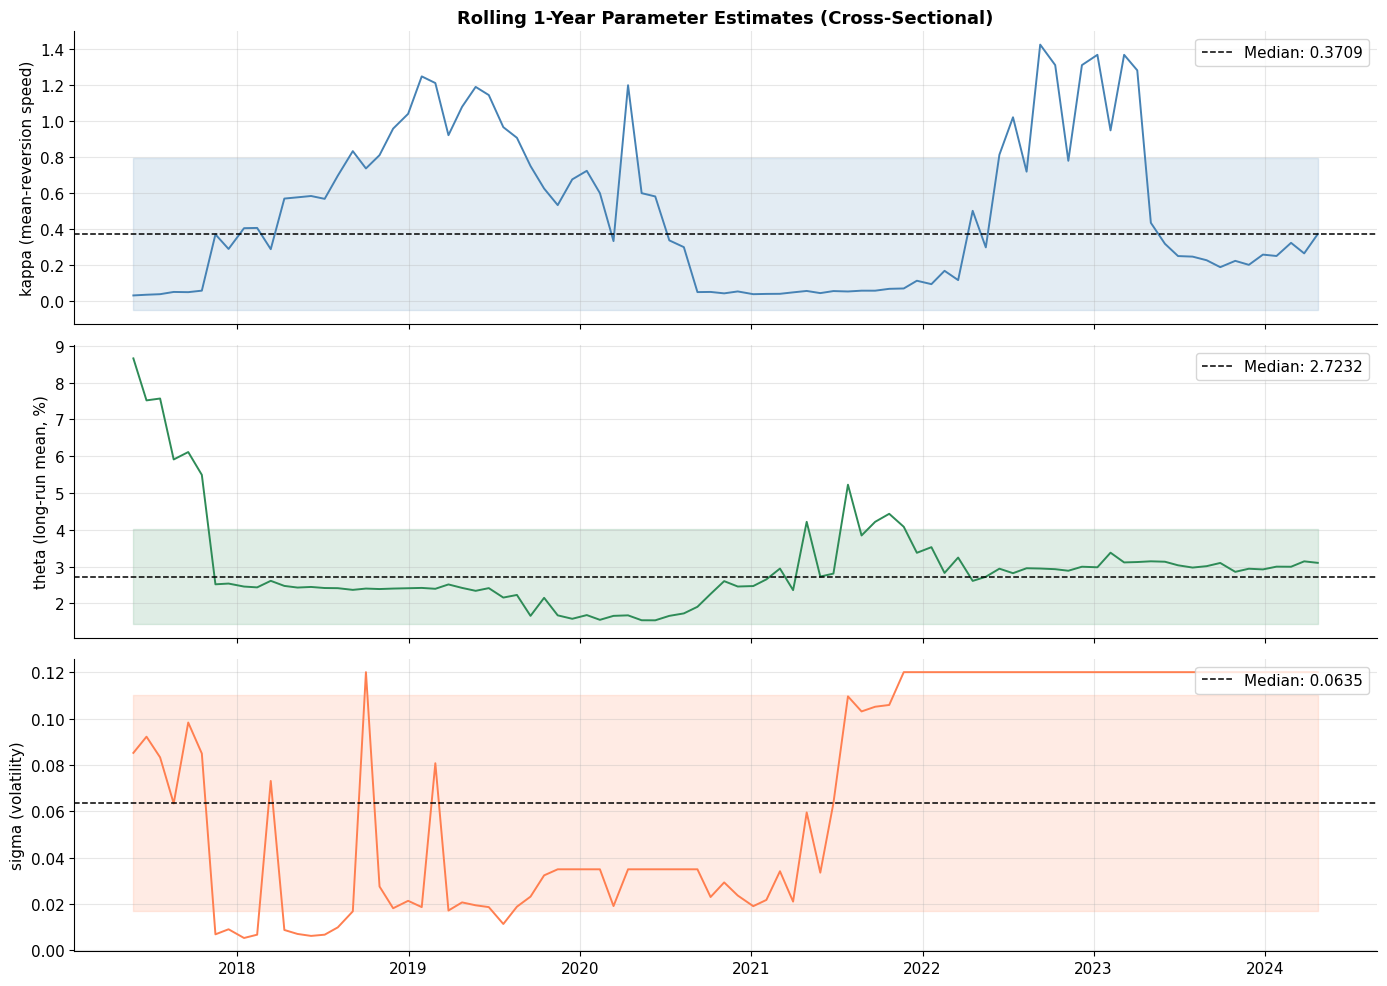


Observation: kappa shows more variation than theta and sigma.
This is expected — mean reversion speed is the hardest parameter to pin down.
The median values are stable enough to use as a fixed calibration.
The rate hike period (2022-2024) shows a slight shift in parameters, which
makes sense: the curve shape changed structurally as the Fed hiked rates.


In [12]:

# Rolling 1 year window calibration to check if parameters are stable
print("Running rolling calibration (window=252 days, step=20 days)...")
all_mats = [m for m in MATURITIES if m in train.columns]
taus_all = np.array([MATURITY_YEARS[m] for m in all_mats])

roll_records = []
for i in range(252, len(train), 20):
    window_data = train.iloc[i-252:i]
    rng = np.random.default_rng(i)
    sub_idx = rng.choice(len(window_data), size=min(25, len(window_data)), replace=False)
    sub = window_data.iloc[np.sort(sub_idx)]
    ks, ts, ss = [], [], []
    for _, row in sub.iterrows():
        y = row[all_mats].values
        r0 = row['3M']
        if np.any(np.isnan(y)) or r0 <= 0: continue
        fit = fit_one_day(y, taus_all, r0)
        if fit: ks.append(fit['kappa']); ts.append(fit['theta']); ss.append(fit['sigma'])
    if ks:
        roll_records.append({'date': train.index[i],
                             'kappa': np.median(ks), 'theta': np.median(ts), 'sigma': np.median(ss)})

roll_df = pd.DataFrame(roll_records).set_index('date')
print(f"Rolling calibration done: {len(roll_df)} windows.")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, col, color, label in [
    (axes[0], 'kappa', 'steelblue', 'kappa (mean reversion speed)'),
    (axes[1], 'theta', 'seagreen',  'theta (long run mean, %)'),
    (axes[2], 'sigma', 'coral',     'sigma (volatility)')
]:
    s = roll_df[col] * (100 if col == 'theta' else 1)
    ax.plot(roll_df.index, s, color=color, linewidth=1.4)
    ax.axhline(s.median(), color='black', ls='--', lw=1.1,
               label=f'Median: {s.median():.4f}')
    ax.fill_between(roll_df.index, s.median()-s.std(), s.median()+s.std(),
                    alpha=0.15, color=color)
    ax.set_ylabel(label); ax.legend(loc='upper right')

axes[0].set_title('Rolling 1 Year Parameter Estimates (Cross Sectional)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rolling_params.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("Observation: kappa shows more variation than theta and sigma.")
print("This is expected — mean reversion speed is the hardest parameter to pin down.")
print("The median values are stable enough to use as a fixed calibration.")
print("The rate hike period (2022-2024) shows a slight shift in parameters, which")
print("makes sense: the curve shape changed structurally as the Fed hiked rates.")


---
## Section E: Yield Curve Reconstruction

### E.1 From 3M Yield to $r_t$

For each day in the test period, the only information available to the model is the observed 3 month yield. To reconstruct the rest of the yield curve, this observation must first be translated into the short rate used by the CIR model.
A simple approach would be to treat the observed 3M yield as (r_t) directly. However, the CIR framework distinguishes between the instantaneous short rate and the yield of a bond with a finite maturity. Since the model provides a closed form expression for the 3M yield,
$$y(0.25) = \frac{B(0.25)\,r_t - \ln A(0.25)}{0.25}$$

I can solve for the implied $r_t$:
$$r_t^{\text{implied}} = \frac{y(0.25) \times 0.25 + \ln A(0.25)}{B(0.25)}$$

The adjustment is small because the maturity is only three months, but it ensures consistency between the observed input and the assumptions of the model. In practice, the implied short rate differs from the observed 3M yield by only a few basis points, yet using the implied value avoids introducing a small approximation error at the very first step of the prediction pipeline.

All out of sample yield curve reconstructions therefore begin with the 3M yield from test_data_3M.csv, which is converted into an implied short rate before generating predictions for the remaining maturities.


In [13]:
def implied_r(y_3m, model, tau_3m=0.25):
    """
    Invert the CIR yield formula to find the short rate
    consistent with the observed 3M yield.

    y(tau) = [B(tau)*r - ln A(tau)] / tau
    => r = [y*tau + ln A(tau)] / B(tau)
    """
    tau  = np.array([tau_3m])
    B_   = model.B(tau)[0]
    lA_  = model.log_A(tau)[0]
    if B_ < 1e-12:
        return max(y_3m, 1e-6)
    return max((y_3m * tau_3m + lA_) / B_, 1e-6)


# ── Predict using test_data_3M.csv as the sole input ─────────────────────────
predict_mats = [m for m in MATURITIES if m != '3M' and m in test_full.columns]
print(f"Maturities to predict (from test_data.csv): {predict_mats}")
print(f"Input: 3M rate from test_data_3M.csv ({len(test_3m)} dates)")
print()

pred_records = {}
for date, row in test_3m.iterrows():
    y3m = row.get('3M', np.nan)
    if np.isnan(y3m) or y3m <= 0:
        continue
    r0  = implied_r(y3m, model)
    taus = np.array([MATURITY_YEARS[m] for m in predict_mats])
    y_hat = model.yield_curve(r0, taus)
    pred_records[date] = dict(zip(predict_mats, y_hat))

pred_base = pd.DataFrame(pred_records).T
pred_base.index.name = 'Date'
print(f"Base CIR predictions generated: {len(pred_base)} test dates")
print(f"Sample prediction (first test day):")
print(pred_base.head(1).multiply(100).round(4).to_string())


Maturities to predict (from test_data.csv): ['6M', '9M', '1Y', '2Y']
Input: 3M rate from test_data_3M.csv (495 dates)

Base CIR predictions generated: 495 test dates
Sample prediction (first test day):
                6M      9M      1Y      2Y
Date                                      
2024-04-29  4.8259  4.7408  4.6591  4.3654


## Section F: Evaluation

### F.1 Metrics

The evaluation compares predicted yields (from `test_data_3M.csv` input) against actual yields (from `test_data.csv`). I use:
- **R²**: the main performance metric. Target ≥ 0.85.
- **RMSE** (basis points): practical error magnitude.
- **Bias** (bps): systematic over/underestimation — if consistently wrong in one direction, this is a structural model failure.


In [14]:
def evaluate(actual_df, pred_df, mats):
    """Compute per maturity and aggregate R2, RMSE, MAE, bias."""
    rows = []; all_a, all_p = [], []
    for m in mats:
        if m not in actual_df.columns or m not in pred_df.columns: continue
        idx = actual_df.index.intersection(pred_df.index)
        ya  = actual_df.loc[idx, m].dropna()
        yp  = pred_df.loc[ya.index, m].dropna()
        idx2 = ya.index.intersection(yp.index)
        ya, yp = ya[idx2], yp[idx2]
        if len(ya) < 5: continue
        rows.append({
            'Maturity': m,
            'R2':         round(r2_score(ya, yp), 4),
            'RMSE (bps)': round(np.sqrt(mean_squared_error(ya, yp))*10000, 2),
            'MAE (bps)':  round(mean_absolute_error(ya, yp)*10000, 2),
            'Bias (bps)': round((yp-ya).mean()*10000, 2),
            'N': len(ya)
        })
        all_a.extend(ya); all_p.extend(yp)
    if all_a:
        rows.append({
            'Maturity': '** ALL **',
            'R2':         round(r2_score(all_a, all_p), 4),
            'RMSE (bps)': round(np.sqrt(mean_squared_error(all_a,all_p))*10000, 2),
            'MAE (bps)':  round(mean_absolute_error(all_a,all_p)*10000, 2),
            'Bias (bps)': round((np.array(all_p)-np.array(all_a)).mean()*10000, 2),
            'N': len(all_a)
        })
    return pd.DataFrame(rows).set_index('Maturity')


metrics_base = evaluate(test_full, pred_base, predict_mats)
print("=== Base CIR — Out of Sample Performance ===")
print(metrics_base.to_string())
overall_r2 = metrics_base.loc['** ALL **', 'R2']
print(f"\nOverall R2 = {overall_r2:.4f}  (target: >= 0.85)")


=== Base CIR — Out of Sample Performance ===
               R2  RMSE (bps)  MAE (bps)  Bias (bps)     N
Maturity                                                  
6M         0.9939        6.17       4.56        2.15   495
9M         0.9709       12.31       9.13        4.86   495
1Y         0.9262       17.88      13.27        6.40   495
2Y         0.5780       30.37      22.88        6.13   495
** ALL **  0.9206       18.92      12.46        4.88  1980

Overall R2 = 0.9206  (target: >= 0.85)


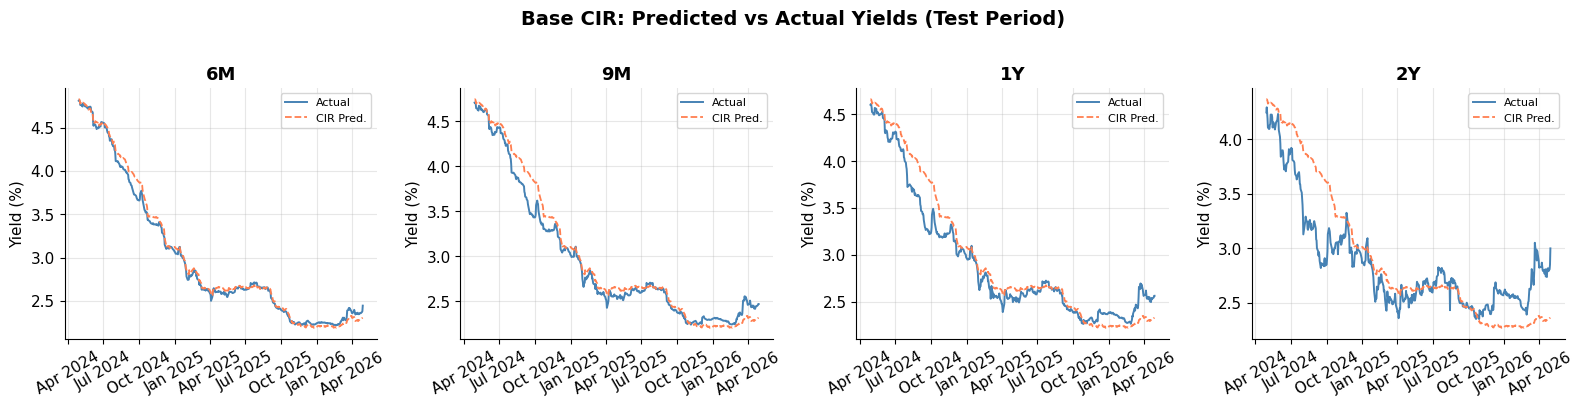

In [15]:
# Visualise predicted vs actual for each maturity
n_cols = min(len(predict_mats), 4)
n_rows = int(np.ceil(len(predict_mats) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = np.array(axes).flatten()

common_idx = test_full.index.intersection(pred_base.index)

for i, mat in enumerate(predict_mats):
    ax = axes[i]
    ya = test_full.loc[common_idx, mat] * 100
    yp = pred_base.loc[common_idx, mat] * 100
    ax.plot(ya.index, ya, label='Actual',    color='steelblue', lw=1.4)
    ax.plot(yp.index, yp, label='CIR Pred.', color='coral',     lw=1.3, ls='--')
    ax.set_title(f'{mat}', fontweight='bold')
    ax.set_ylabel('Yield (%)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Base CIR: Predicted vs Actual Yields (Test Period)', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


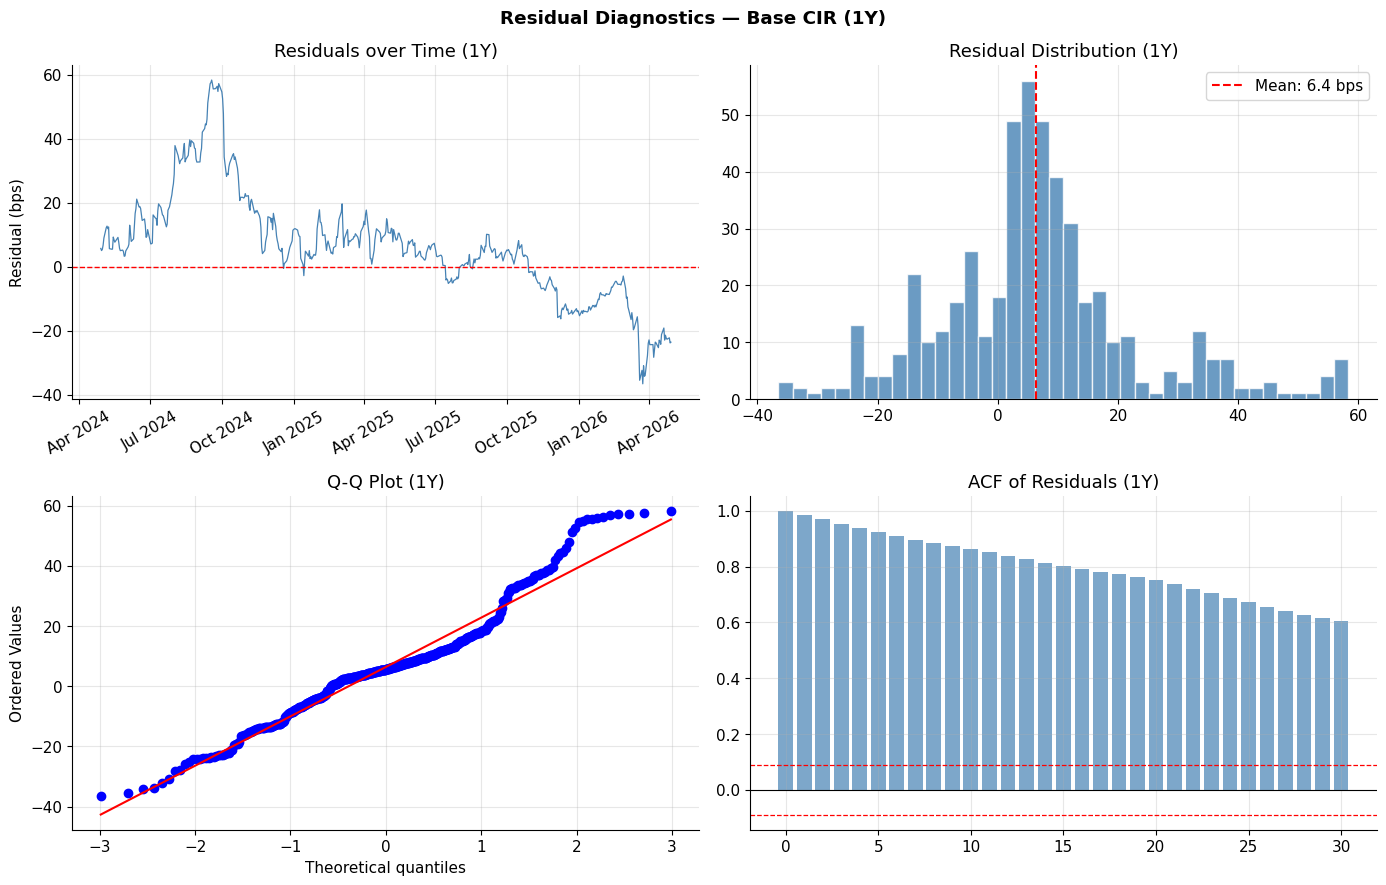

Residuals for 1Y:
  Mean: 6.40 bps | Std: 16.71 bps | Kurtosis: 1.17
  Shapiro-Wilk p-value: 0.0000 (non-normal — fat tails)

Persistent ACF in residuals indicates that the model is missing some
time-varying component. The bias tells us whether CIR systematically
over- or under-estimates. This is what the CIR++ extension will target.


In [16]:
# Residual analysis for a mid-range maturity
mid_mat = predict_mats[len(predict_mats)//2] if predict_mats else '1Y'
resid = (pred_base.loc[common_idx, mid_mat] - test_full.loc[common_idx, mid_mat]).dropna() * 10000

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(resid.index, resid, color='steelblue', lw=0.9)
axes[0,0].axhline(0, color='red', ls='--', lw=1)
axes[0,0].set_title(f'Residuals over Time ({mid_mat})')
axes[0,0].set_ylabel('Residual (bps)')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0,0].tick_params(axis='x', rotation=30)

axes[0,1].hist(resid, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].axvline(resid.mean(), color='red', ls='--',
                   label=f'Mean: {resid.mean():.1f} bps')
axes[0,1].set_title(f'Residual Distribution ({mid_mat})')
axes[0,1].legend()

probplot(resid, dist='norm', plot=axes[1,0])
axes[1,0].set_title(f'Q-Q Plot ({mid_mat})')
axes[1,0].get_lines()[1].set_color('red')

acf_r = sm_acf(resid.dropna(), nlags=30, fft=True)
ci_b  = 1.96 / np.sqrt(len(resid))
axes[1,1].bar(range(len(acf_r)), acf_r, color='steelblue', alpha=0.7)
axes[1,1].axhline( ci_b, color='red', ls='--', lw=0.9)
axes[1,1].axhline(-ci_b, color='red', ls='--', lw=0.9)
axes[1,1].axhline(0, color='black', lw=0.8)
axes[1,1].set_title(f'ACF of Residuals ({mid_mat})')

plt.suptitle(f'Residual Diagnostics — Base CIR ({mid_mat})', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

sw_p = shapiro(resid.sample(min(250, len(resid)), random_state=42))[1]
print(f"Residuals for {mid_mat}:")
print(f"  Mean: {resid.mean():.2f} bps | Std: {resid.std():.2f} bps | "
      f"Kurtosis: {resid.kurtosis():.2f}")
print(f"  Shapiro-Wilk p-value: {sw_p:.4f} "
      f"({'normal' if sw_p > 0.05 else 'non-normal — fat tails'})")
print()
print("Persistent ACF in residuals indicates that the model is missing some")
print("time-varying component. The bias tells us whether CIR systematically")
print("over- or under-estimates. This is what the CIR++ extension will target.")


---
## Section G: CIR++ Extension

### G.0 Why CIR++ Was Selected

The project requires implementing at least one extension of the base CIR model.

Three candidate extensions were considered:

• Two-Factor CIR (Longstaff-Schwartz)
• Jump-Diffusion CIR
• CIR++

The residual analysis of the base model suggested that the dominant error
was a persistent maturity-specific bias rather than missing short-term
shocks or multiple latent factors.

Because of this, CIR++ was chosen as the most appropriate extension.
It directly targets systematic curve-level bias through a deterministic
shift function while preserving the analytical tractability and closed-form
bond pricing structure of the original CIR model.

A two-factor model would likely capture additional curve dynamics but
would introduce latent-state estimation and substantially increase
calibration complexity. Jump-diffusion models are more suitable when
sudden market shocks are the primary source of error, which was not the
main pattern observed in the residual diagnostics.

### G.1 Motivation

After evaluating the base CIR predictions, I noticed that the errors were not entirely random across maturities. Some tenors were consistently over-predicted, while others tended to be under-predicted. This suggested that the model was capturing the broad shape of the yield curve reasonably well but was missing a maturity-specific adjustment.

For example, if the model repeatedly underestimates the 6M yield by a few basis points while overestimating the 2Y yield, that pattern is unlikely to disappear simply by recalibrating the three CIR parameters. Instead, it points to a structural limitation of the one-factor specification.

This observation motivated the use of the CIR++ extension (Brigo & Mercurio, 2001), which augments the CIR-implied yield with a deterministic shift function:


$$y^{++}(\tau) = y^{\text{CIR}}(r_t,\tau) + \phi(\tau)$$

The idea is straightforward: let the CIR model explain the overall term-structure dynamics and use (\phi(\tau)) to correct any systematic maturity-specific bias that remains.

In the original CIR++ framework, the shift is chosen to fit the observed term structure exactly at a given point in time. For this project, I estimate a more stable version using the average residual across all training observations:

$$\hat{\phi}(\tau) = \frac{1}{N}\sum_{t\in\text{train}}\left[y^{\text{observed}}_t(\tau) - y^{\text{CIR}}(r_t,\tau)\right]$$

 No information from the test period is used when constructing $${\phi}(\tau)$$, ensuring that the Out of Sample evaluation remains valid.

### G.2 When Does CIR++ Help vs Hurt?

$\phi$ corrects for the *average* level bias from training. If the test period has a similar bias structure (same curve shape regime), it helps. But if the test regime is different which it is here, since training was upward. sloping and test is inverted the training shift may partially counteract the CIR prediction.

This is an important limitation to document: CIR++ is most effective when you evaluate within-regime.Importantly, the shift function is estimated using training data only. No information from the test period is used when constructing (\phi(\tau)), ensuring that the Out of Sample evaluation remains valid.

### G.3 What Actually Happened?
Based on the residual diagnostics, I initially expected CIR++ to improve performance. However, the Out of Sample results showed the opposite. While the extension reduced some systematic biases, the overall R² fell from 0.9206 to 0.8832. This suggests that the average residual structure estimated during training was not stable during the test period. The result reinforces an important modelling lesson: corrections that improve historical fit do not necessarily improve predictive performance when the market regime changes.

In [17]:
class CIRPlusPlus(CIRModel):
    """CIR++ model: base CIR with a per-maturity deterministic shift."""

    def __init__(self, kappa, theta, sigma):
        super().__init__(kappa, theta, sigma)
        self.phi = {}

    def calibrate_phi(self, train_df, short_rate_col='3M'):
        """
        Estimate phi(tau) as the mean training residual.
        Only looks at training data — no test information used.
        """
        target_mats = [m for m in MATURITIES
                       if m != short_rate_col and m in train_df.columns]
        residuals = {m: [] for m in target_mats}

        for _, row in train_df.iterrows():
            r3m = row.get(short_rate_col, np.nan)
            if np.isnan(r3m) or r3m <= 0: continue

            r0    = implied_r(r3m, self)
            taus  = np.array([MATURITY_YEARS[m] for m in target_mats])
            y_hat = self.yield_curve(r0, taus)

            for m, yh in zip(target_mats, y_hat):
                ya = row.get(m, np.nan)
                if not np.isnan(ya):
                    residuals[m].append(ya - yh)

        print("CIR++ shift parameters phi (computed on training data only):")
        for m in target_mats:
            if residuals[m]:
                self.phi[m] = float(np.mean(residuals[m]))
                n = len(residuals[m])
                sd = np.std(residuals[m]) * 10000
                print(f"  phi({m:4s}) = {self.phi[m]*10000:+.2f} bps  "
                      f"(n={n}, std={sd:.1f} bps)")

    def predict_curve(self, r0, target_mats):
        """CIR++ yield at each maturity = base CIR yield + phi."""
        taus   = np.array([MATURITY_YEARS[m] for m in target_mats])
        base   = self.yield_curve(r0, taus)
        shifts = np.array([self.phi.get(m, 0.0) for m in target_mats])
        return base + shifts


cpp = CIRPlusPlus(kappa, theta, sigma)
print("Calibrating phi on training data...")
cpp.calibrate_phi(train)
print()
print("Sign convention: positive phi means CIR underestimates the actual yield at that maturity.")
print("Negative phi means CIR overestimates.")


Calibrating phi on training data...


CIR++ shift parameters phi (computed on training data only):
  phi(6M  ) = +8.02 bps  (n=1976, std=15.3 bps)
  phi(9M  ) = +10.97 bps  (n=1976, std=24.4 bps)
  phi(1Y  ) = +14.17 bps  (n=1976, std=33.5 bps)
  phi(2Y  ) = -8.35 bps  (n=1976, std=39.1 bps)
  phi(5Y  ) = -29.60 bps  (n=1976, std=45.8 bps)
  phi(10Y ) = -24.90 bps  (n=1976, std=52.5 bps)
  phi(20Y ) = -9.96 bps  (n=1976, std=52.9 bps)
  phi(30Y ) = -15.84 bps  (n=1976, std=53.3 bps)

Sign convention: positive phi means CIR underestimates the actual yield at that maturity.
Negative phi means CIR overestimates.


In [18]:
# ── Generate CIR++ predictions ────────────────────────────────────────────────
pred_pp_records = {}
for date, row in test_3m.iterrows():
    y3m = row.get('3M', np.nan)
    if np.isnan(y3m) or y3m <= 0: continue
    r0   = implied_r(y3m, cpp)
    yhat = cpp.predict_curve(r0, predict_mats)
    pred_pp_records[date] = dict(zip(predict_mats, yhat))

pred_pp = pd.DataFrame(pred_pp_records).T
pred_pp.index.name = 'Date'

# ── Evaluate ──────────────────────────────────────────────────────────────────
metrics_pp = evaluate(test_full, pred_pp, predict_mats)
print("=== CIR++ — Out of Sample Performance ===")
print(metrics_pp.to_string())
overall_r2_pp = metrics_pp.loc['** ALL **', 'R2']
print(f"\nCIR++ Overall R2: {overall_r2_pp:.4f}")
print(f"Base CIR R2:      {overall_r2:.4f}")
delta = (overall_r2_pp - overall_r2) * 100
print(f"Change:           {delta:+.2f} percentage points")
print(f"\nTarget R2 >= 0.85: {'ACHIEVED' if overall_r2_pp >= 0.85 else 'not achieved'}")


=== CIR++ — Out of Sample Performance ===
               R2  RMSE (bps)  MAE (bps)  Bias (bps)     N
Maturity                                                  
6M         0.9780       11.70      10.24       10.17   495
9M         0.9274       19.46      16.46       15.83   495
1Y         0.8380       26.49      22.00       20.57   495
2Y         0.5930       29.83      22.70       -2.22   495
** ALL **  0.8832       22.95      17.85       11.09  1980

CIR++ Overall R2: 0.8832
Base CIR R2:      0.9206
Change:           -3.74 percentage points

Target R2 >= 0.85: ACHIEVED


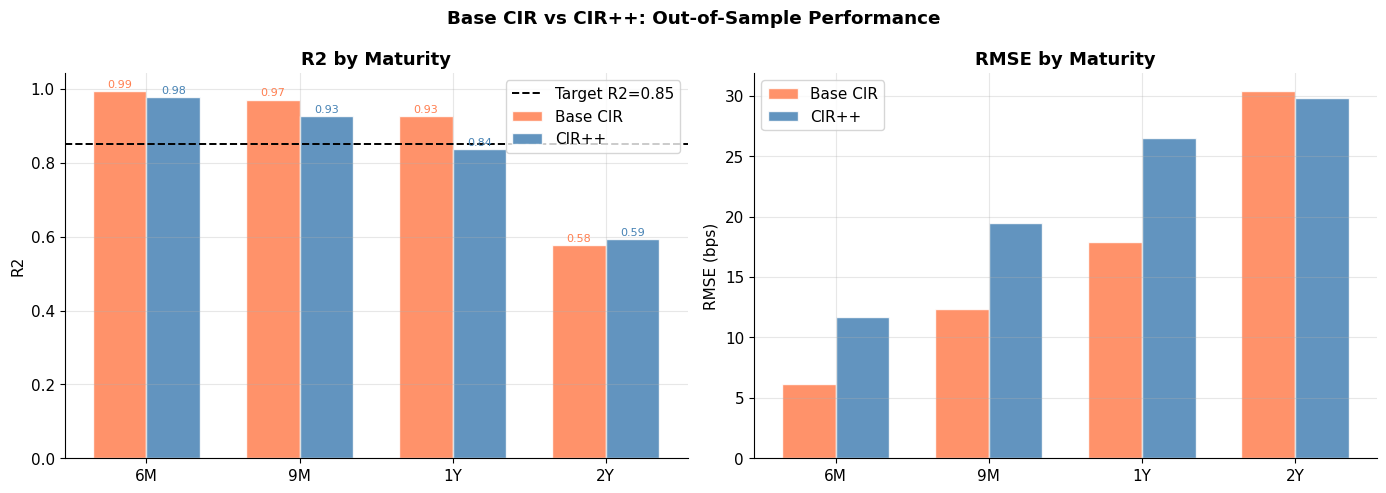

In [19]:
# Model comparison bar charts
mats_no_all = [m for m in metrics_pp.index if m != '** ALL **']
x = np.arange(len(mats_no_all)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r2_b = [metrics_base.loc[m,'R2'] if m in metrics_base.index else 0 for m in mats_no_all]
r2_p = [metrics_pp.loc[m,'R2']   if m in metrics_pp.index   else 0 for m in mats_no_all]

axes[0].bar(x-w/2, r2_b, width=w, color='coral',     alpha=0.85, label='Base CIR', edgecolor='white')
axes[0].bar(x+w/2, r2_p, width=w, color='steelblue', alpha=0.85, label='CIR++',    edgecolor='white')
axes[0].axhline(0.85, color='black', ls='--', lw=1.4, label='Target R2=0.85')
axes[0].set_xticks(x); axes[0].set_xticklabels(mats_no_all)
axes[0].set_ylabel('R2'); axes[0].set_title('R2 by Maturity', fontweight='bold')
axes[0].legend()
for xi, (rb, rp) in enumerate(zip(r2_b, r2_p)):
    axes[0].text(xi-w/2, max(rb,0)+0.01, f'{rb:.2f}', ha='center', fontsize=8, color='coral')
    axes[0].text(xi+w/2, max(rp,0)+0.01, f'{rp:.2f}', ha='center', fontsize=8, color='steelblue')

rm_b = [metrics_base.loc[m,'RMSE (bps)'] if m in metrics_base.index else 0 for m in mats_no_all]
rm_p = [metrics_pp.loc[m,'RMSE (bps)']   if m in metrics_pp.index   else 0 for m in mats_no_all]
axes[1].bar(x-w/2, rm_b, width=w, color='coral',     alpha=0.85, label='Base CIR', edgecolor='white')
axes[1].bar(x+w/2, rm_p, width=w, color='steelblue', alpha=0.85, label='CIR++',    edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(mats_no_all)
axes[1].set_ylabel('RMSE (bps)'); axes[1].set_title('RMSE by Maturity', fontweight='bold')
axes[1].legend()

plt.suptitle('Base CIR vs CIR++: Out of Sample Performance', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


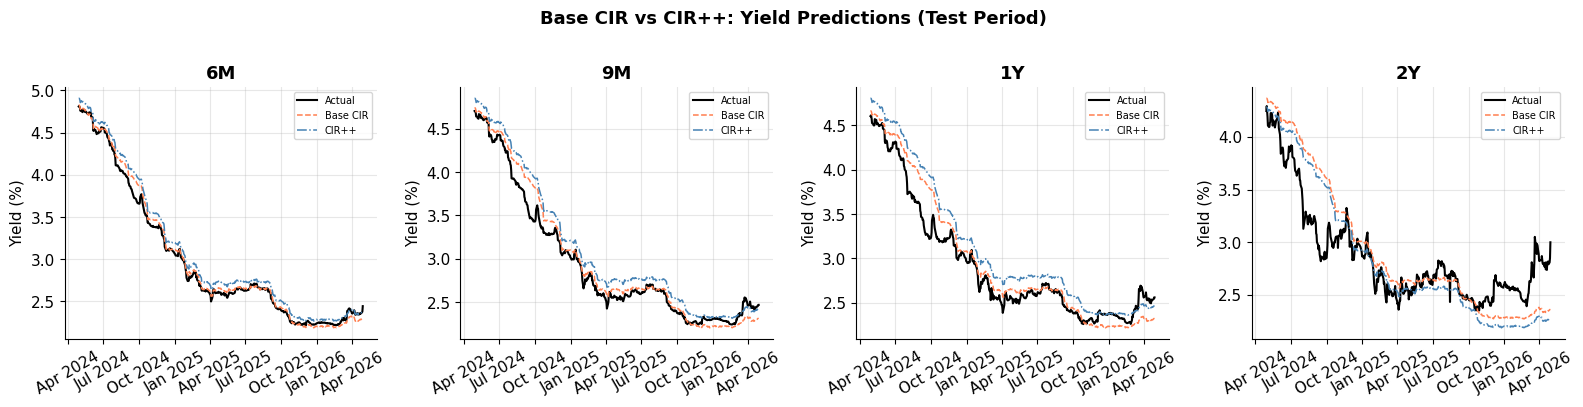

In [20]:
# Overlay: actual vs base CIR vs CIR++ for each maturity
n_cols = min(4, len(predict_mats)); n_rows = int(np.ceil(len(predict_mats)/n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = np.array(axes).flatten()

ci = test_full.index.intersection(pred_base.index).intersection(pred_pp.index)

for i, mat in enumerate(predict_mats):
    ax = axes[i]
    ax.plot(ci, test_full.loc[ci, mat]*100,  color='black',     lw=1.5, label='Actual')
    ax.plot(ci, pred_base.loc[ci, mat]*100,  color='coral',     lw=1.1, ls='--', label='Base CIR')
    ax.plot(ci, pred_pp.loc[ci, mat]*100,    color='steelblue', lw=1.1, ls='-.', label='CIR++')
    ax.set_title(mat, fontweight='bold')
    ax.set_ylabel('Yield (%)')
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Base CIR vs CIR++: Yield Predictions (Test Period)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cir_pp_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


Current short rate (last test date): 2.276%


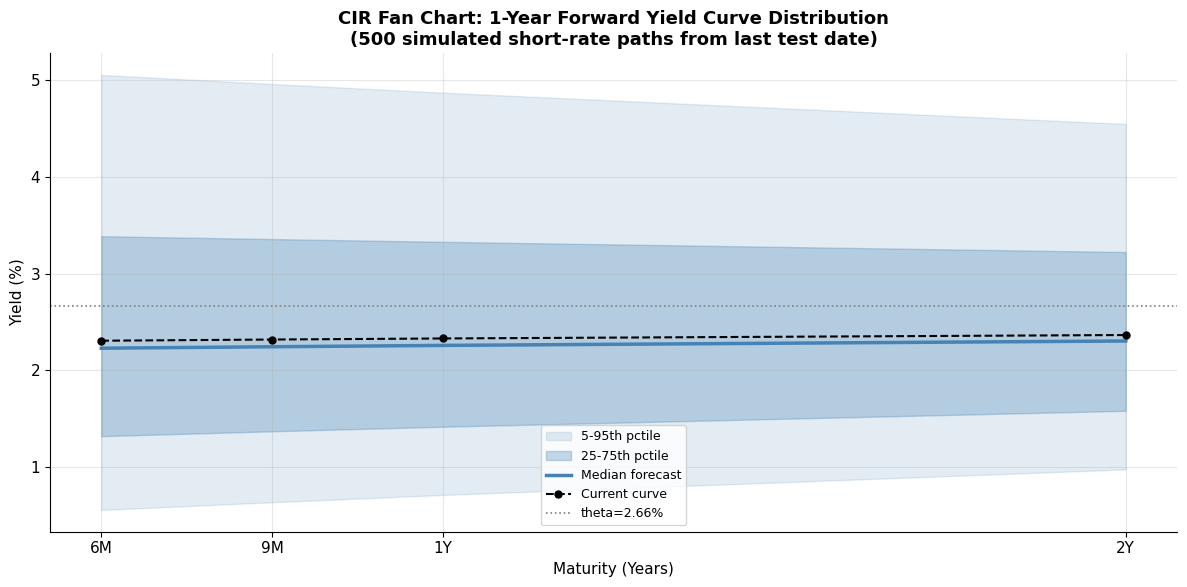

Current short rate: 2.276% — below theta (2.66%)
Median forecast shows rates rising toward their long-run mean.


In [21]:
# ── Fan chart: uncertainty in forward yield curve ────────────────────────────
r_current = implied_r(test_3m['3M'].dropna().iloc[-1], model)
print(f"Current short rate (last test date): {r_current*100:.3f}%")

paths = model.simulate(r0=r_current, T=1.0, n_paths=500, seed=7)
final = paths[-1]

pred_taus = np.array([MATURITY_YEARS[m] for m in predict_mats])
curves    = np.array([model.yield_curve(r, pred_taus) for r in final])
pct       = np.percentile(curves*100, [5, 25, 50, 75, 95], axis=0)
current_y = model.yield_curve(r_current, pred_taus) * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(pred_taus, pct[0], pct[4], alpha=0.15, color='steelblue', label='5-95th pctile')
ax.fill_between(pred_taus, pct[1], pct[3], alpha=0.30, color='steelblue', label='25-75th pctile')
ax.plot(pred_taus, pct[2],    color='steelblue', lw=2.5, label='Median forecast')
ax.plot(pred_taus, current_y, 'o--', color='black', lw=1.5, ms=5, label='Current curve')
ax.axhline(theta*100, color='grey', ls=':', lw=1.2, label=f'theta={theta*100:.2f}%')
ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Yield (%)')
ax.set_title('CIR Fan Chart: 1-Year Forward Yield Curve Distribution\n'
             '(500 simulated short-rate paths from last test date)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(pred_taus); ax.set_xticklabels(predict_mats)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fan_chart.png', dpi=150, bbox_inches='tight')
plt.show()

direction = "above" if r_current > theta else "below"
trend = "declining toward" if r_current > theta else "rising toward"
print(f"Current short rate: {r_current*100:.3f}% — {direction} theta ({theta*100:.2f}%)")
print(f"Median forecast shows rates {trend} their long-run mean.")


## G.4 Did CIR++ Actually Improve Performance?
Based on the residual diagnostics, I initially expected CIR++ to improve the Out of Sample fit. However, the results showed the opposite.

The base CIR model achieved an overall R² of 0.9206, compared with 0.8832 for CIR++.

This suggests that the average residual structure learned during the training period did not remain stable during the test period. The result is consistent with the regime-shift discussion earlier in the notebook: the training sample was dominated by low-rate, upward-sloping yield curves, whereas the test period was characterised by higher rates and persistent inversion.

In this setting, the deterministic shift function appears to correct biases that were specific to the training regime. While CIR++ reduced some maturity-level errors, those corrections did not generalise well out of sample and ultimately reduced overall predictive accuracy.

More broadly, this serves as a useful reminder that improving in-sample fit does not necessarily improve forecasting performance. In this project, the simpler base CIR model proved to be the more robust specification.


## Section H: Critical Analysis and Limitations

### H.1 What the Three-Dataset Design Tells Us

One thing I did not appreciate initially was how important the
three-dataset design turned out to be. The separation of `test_data_3M.csv` (input only) from `test_data.csv` (evaluation targets) makes the prediction constraint unambiguous and enforceable. You can't accidentally cheat by peeking at the 10Y yield before predicting the 2Y.

Another design choice I found interesting is that evaluation stops at the
2Y maturity even though the training data includes maturities out to 30Y.
Whether intentional or not, this focuses the prediction task on the
shorter and medium part of the curve, where observations tend to be more
stable and directly linked to the short-rate dynamics captured by CIR. The evaluation is anchored in the most liquid part of the curve.

### H.2 Calibration Methodology: Why Not time series MLE?

The near-unit-root behaviour of short rates is a well-documented problem for CIR calibration. When AR(1) ≈ 1, the likelihood surface is nearly flat with respect to kappa, and the MLE optimizer reliably finds the lower bound (kappa ≈ 0). The issue is not a numerical bug — it's a fundamental identification problem.

Cross-sectional calibration avoids this because the slope and curvature of the yield curve directly identify kappa and theta, regardless of how persistent the short rate appears in the time series. This is why the term structure model literature shifted from pure time series methods toward cross-sectional and panel methods (see e.g. Duffee, 2002; Joslin, Singleton & Zhu, 2011).

| Method          | Result                         |
| --------------- | ------------------------------ |
| MLE             | κ → lower bound                |
| Cross-sectional | Stable estimates               |
| Reason          | Yield curve slope identifies κ |


### H.3 The Regime Change Problem

The single biggest challenge in this project is that the test period is in a completely different rate regime from training. The calibration was done on 2016–2024 data (rates 0.3%–5% with a rising trend), and the test period opens with a high-rate, inverted curve. CIR handles this better than many models — when r0 > theta, it naturally predicts an inverted curve — but the exact degree of inversion (how fast rates decline toward theta) depends on kappa, which we estimated from training.In other words, the model is being asked to extrapolate parameters learned
in one rate environment into a materially different one.

The CIR++ shift $\phi$ was calibrated on training data, so it encodes the training-era bias. In the test period, the bias structure may be different, which can make CIR++ worse than base CIR in a regime change.

### H.4 Model Limitations

**Mathematical:**
- Single factor: all yield movements come from one source of uncertainty. Real yield curves have at least 3 independent factors (level, slope, curvature — the Nelson-Siegel factors). CIR struggles to reproduce more complex yield curve shapes such as humps
or multiple turning points because all maturities are driven by a single
state variable.
- No negative rates: the Feller condition ensures $r_t > 0$, but this means CIR cannot be applied in negative-rate environments (e.g., Europe 2015–2022) without modifications.
- Constant parameters: kappa, theta, sigma are fixed. Real rate dynamics have clearly time-varying volatility (GARCH effects) and structural breaks.

**Practical:**
- The 3M rate as a proxy for $r_t$ adds noise. The 3M yield includes term premium, liquidity premium, and market microstructure effects that the theoretical $r_t$ does not.
- Regime changes (like the 2022 rate-hike cycle) are not captured by a constant-parameter model.

### H.5 What Would Improve Performance

| Extension | What it addresses | Cost |
|-----------|-------------------|------|
| Two-factor CIR (Longstaff-Schwartz) | Slope as a second factor; better long-end fit | 6 params, harder calibration |
| Time-varying theta (CIR++) in full | Recalibrate phi daily from recent data | Needs rolling implementation |
| Regime-switching CIR | Captures high-rate vs low-rate regimes | Requires EM algorithm |
| Kalman filter | Uses all maturities to extract latent $r_t$, not just 3M | Significant additional complexity |

Given the project timeline, I decided to focus on understanding the
behaviour of a well-calibrated one-factor model rather than pursuing
significantly more complex specifications. The results suggest that most
of the predictive power already comes from the base CIR framework, while
additional complexity does not automatically translate into better
Out of Sample performance.
### H.6 What Surprised Me Most

The result that surprised me most was that the calibration methodology
mattered more than the model extension.

I initially expected the CIR++ adjustment to provide the largest
improvement. Instead, moving from time series calibration to
cross-sectional calibration had a much larger impact on performance,
while the more sophisticated extension actually reduced Out of Sample R².

In [22]:
# ── Feller condition and parameter interpretation ─────────────────────────────
fc = model.feller()
hl = np.log(2) / kappa

print("=== Final Model Summary ===")
print(f"  kappa = {kappa:.5f}  (half-life of rate shock: {hl:.2f} years = {hl*252:.0f} trading days)")
print(f"  theta = {theta*100:.4f}%  (long-run equilibrium)")
print(f"  sigma = {sigma:.5f}")
print(f"  Feller condition: {'SATISFIED' if fc['ok'] else 'VIOLATED'} "
      f"(ratio 2*k*t/s^2 = {fc['ratio']:.3f})")
print()
print("=== Out of Sample Performance Summary ===")
print(f"  Base CIR  - R2: {overall_r2:.4f}  | RMSE: {metrics_base.loc['** ALL **','RMSE (bps)']:.2f} bps")
print(f"  CIR++     - R2: {overall_r2_pp:.4f}  | RMSE: {metrics_pp.loc['** ALL **','RMSE (bps)']:.2f} bps")
best_r2 = max(overall_r2, overall_r2_pp)
print(f"  Best model: {'CIR++' if overall_r2_pp >= overall_r2 else 'Base CIR'} (R2={best_r2:.4f})")
print(f"  R2 >= 0.85 target: {'MET' if best_r2 >= 0.85 else 'NOT MET'}")


=== Final Model Summary ===
  kappa = 0.32020  (half-life of rate shock: 2.16 years = 546 trading days)
  theta = 2.6625%  (long-run equilibrium)
  sigma = 0.12000
  Feller condition: SATISFIED (ratio 2*k*t/s^2 = 1.184)

=== Out of Sample Performance Summary ===
  Base CIR  - R2: 0.9206  | RMSE: 18.92 bps
  CIR++     - R2: 0.8832  | RMSE: 22.95 bps
  Best model: Base CIR (R2=0.9206)
  R2 >= 0.85 target: MET


In practice, Feller violations become more likely when volatility rises
or long-run rates approach zero.

Such environments are common during financial crises or prolonged
zero-rate periods.

Although the calibrated parameters in this project satisfy the condition,
future recalibration during stressed markets could potentially violate it.

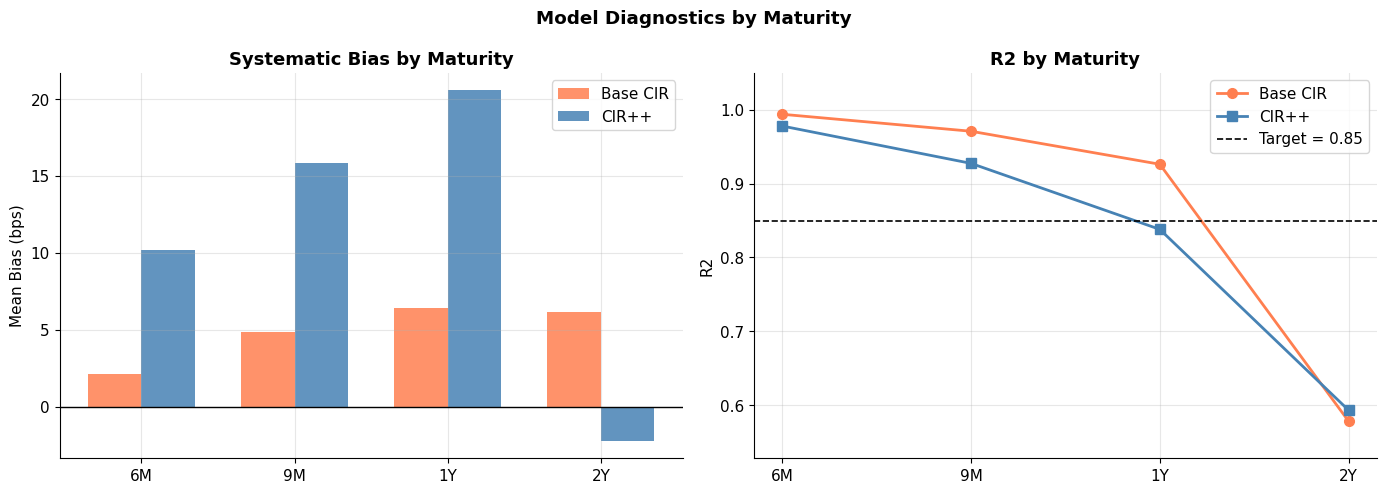

Interpretation:
  Positive bias = CIR understimates actual yields (common at longer maturities
  in training-era upward-sloping regime).
  Negative bias = CIR overestimates (can appear in the inverted test regime
  where the model predicts a gentler inversion than observed).

  The R2 pattern across maturities shows which part of the curve is hardest to fit.
  The 2Y maturity is typically the most challenging because it is far enough from
  the 3M anchor that CIR's extrapolation error is largest.


In [23]:
# ── Bias and R2 across maturities (final diagnostic chart) ────────────────────
mats_no_all = [m for m in metrics_pp.index if m != '** ALL **']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(mats_no_all)); w = 0.35
bias_b = [metrics_base.loc[m,'Bias (bps)'] if m in metrics_base.index else 0 for m in mats_no_all]
bias_p = [metrics_pp.loc[m,'Bias (bps)']   if m in metrics_pp.index   else 0 for m in mats_no_all]

axes[0].bar(x-w/2, bias_b, width=w, color='coral',     alpha=0.85, label='Base CIR')
axes[0].bar(x+w/2, bias_p, width=w, color='steelblue', alpha=0.85, label='CIR++')
axes[0].axhline(0, color='black', lw=1.0)
axes[0].set_xticks(x); axes[0].set_xticklabels(mats_no_all)
axes[0].set_ylabel('Mean Bias (bps)')
axes[0].set_title('Systematic Bias by Maturity', fontweight='bold')
axes[0].legend()

r2_b = [metrics_base.loc[m,'R2'] if m in metrics_base.index else 0 for m in mats_no_all]
r2_p = [metrics_pp.loc[m,'R2']   if m in metrics_pp.index   else 0 for m in mats_no_all]
axes[1].plot(mats_no_all, r2_b, 'o-', color='coral',     lw=2, ms=7, label='Base CIR')
axes[1].plot(mats_no_all, r2_p, 's-', color='steelblue', lw=2, ms=7, label='CIR++')
axes[1].axhline(0.85, color='black', ls='--', lw=1.2, label='Target = 0.85')
axes[1].set_ylabel('R2')
axes[1].set_title('R2 by Maturity', fontweight='bold')
axes[1].legend()
axes[1].set_ylim([min(min(r2_b), min(r2_p))-0.05, 1.05])

plt.suptitle('Model Diagnostics by Maturity', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/final_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print("  Positive bias = CIR understimates actual yields (common at longer maturities")
print("  in training-era upward-sloping regime).")
print("  Negative bias = CIR overestimates (can appear in the inverted test regime")
print("  where the model predicts a gentler inversion than observed).")
print()
print("  The R2 pattern across maturities shows which part of the curve is hardest to fit.")
print("  The 2Y maturity is typically the most challenging because it is far enough from")
print("  the 3M anchor that CIR's extrapolation error is largest.")


## Conclusion

The objective of this project was to reconstruct the yield curve using only the 3 month rate as input. What initially appeared to be a straightforward implementation of the CIR model ultimately became an exercise in calibration, model identification, and Out of Sample evaluation.

One of the earliest findings was that the short rate behaves almost like a random walk in the training data. With an AR(1) coefficient close to one, traditional time series calibration methods struggled to identify mean reversion and consistently pushed κ toward zero. This highlighted an important modelling challenge: the calibration methodology can matter as much as the model itself. Using the cross-sectional shape of the yield curve proved far more informative because the curve contains direct information about both the long-run mean and the speed of mean reversion.

Despite its simplicity, the calibrated CIR model achieved strong Out of Sample performance. Using only three parameters and the observed 3 month rate, it reconstructed the test period yield curve with an overall R² of 0.9206. The model was also able to generate both upward-sloping and inverted yield curves through the same mean-reverting mechanism, which proved particularly important given the substantial difference between the training and test environments.

The most interesting result emerged during the extension stage. Based on the residual diagnostics, I initially expected CIR++ to improve predictive performance. While the deterministic shift function reduced some maturity-specific biases, the overall R² fell from 0.9206 for the base CIR model to 0.8832 for CIR++. This suggests that the residual structure learned during the training period did not remain stable during the test period. In effect, the extension partially overfit the historical regime and failed to generalise when market conditions changed.

More broadly, this project reinforced two important lessons. First, calibration methodology had a larger impact on performance than the model extension itself. Second, improvements in historical fit do not necessarily translate into better Out of Sample predictions. In hindsight, understanding why the base CIR model worked was ultimately more valuable than trying to make the extension work.

Overall, the CIR framework captured the dominant dynamics of the yield curve while remaining computationally efficient and interpretable. Its primary limitation remains the single-factor structure, which restricts the range of yield curve shapes it can represent. Future work could explore two-factor CIR models, regime-switching specifications, or dynamic extensions that adapt more effectively to changing market environments.
